In [52]:
import pandas as pd
from sqlalchemy import create_engine
from models.data_prep import prepare_data, FEATURE_COLS
import sys
sys.path.append("..")
from config import DB_URL

engine = create_engine(DB_URL)
matrix = pd.read_sql("SELECT * FROM feature_matrix", engine)
print(f"Shape: {matrix.shape}")
matrix.head()

Shape: (25, 30)


,match_id,match_date,team1,team2,winner,venue,toss_winner,team1_win_rate,team2_win_rate,avg_team1_runs,...,toss_won_by_team1,team1_toss_advantage,team2_toss_advantage,team1_bat_avg,team2_bat_avg,bat_avg_diff,team1_bowl_eco,team2_bowl_eco,bowl_eco_diff,team1_won
0,9001,2026-03-25,Dummy Team A,Dummy Team B,Dummy Team A,Stadium A,Dummy Team A,0.60,0.40,170.0,...,NaN,NaN,NaN,42.5,38.1,NaN,7.2,7.8,NaN,1
1,9002,2026-03-26,Dummy Team C,Dummy Team D,Dummy Team D,Stadium B,Dummy Team C,0.55,0.45,165.0,...,NaN,NaN,NaN,40.1,39.0,NaN,6.9,7.3,NaN,0
2,9003,2026-03-27,Dummy Team A,Dummy Team C,Dummy Team C,Stadium C,Dummy Team A,0.50,0.50,168.0,...,NaN,NaN,NaN,41.0,40.5,NaN,7.0,7.1,NaN,0
3,9004,2026-03-28,Dummy Team B,Dummy Team D,Dummy Team B,Stadium D,Dummy Team D,0.52,0.48,160.0,...,NaN,NaN,NaN,39.5,37.2,NaN,6.8,7.0,NaN,1
4,9005,2026-03-29,Dummy Team A,Dummy Team D,Dummy Team D,Stadium A,Dummy Team A,0.57,0.43,172.0,...,NaN,NaN,NaN,43.0,38.8,NaN,7.1,7.5,NaN,0


In [53]:
null_counts = matrix.isnull().sum()
null_pct    = (matrix.isnull().sum() / len(matrix) * 100).round(2)

null_report = pd.DataFrame({
    "null_count": null_counts,
    "null_pct":   null_pct
}).query("null_count > 0")

if null_report.empty:
    print("No nulls found — clean matrix!")
else:
    print("Columns with nulls:")
    print(null_report)

Columns with nulls:
                      null_count  null_pct
win_rate_diff                 23      92.0
team1_streak                  23      92.0
team2_streak                  23      92.0
team1_h2h_win_rate            23      92.0
team2_h2h_win_rate            23      92.0
h2h_total                     23      92.0
team1_venue_win_rate          23      92.0
team2_venue_win_rate          23      92.0
venue_advantage_diff          23      92.0
toss_won_by_team1             23      92.0
team1_toss_advantage          23      92.0
team2_toss_advantage          23      92.0
bat_avg_diff                  23      92.0
bowl_eco_diff                 23      92.0


Target balance:
  team1 won  : 9 matches (36.0%)
  team1 lost : 16 matches (64.0%)


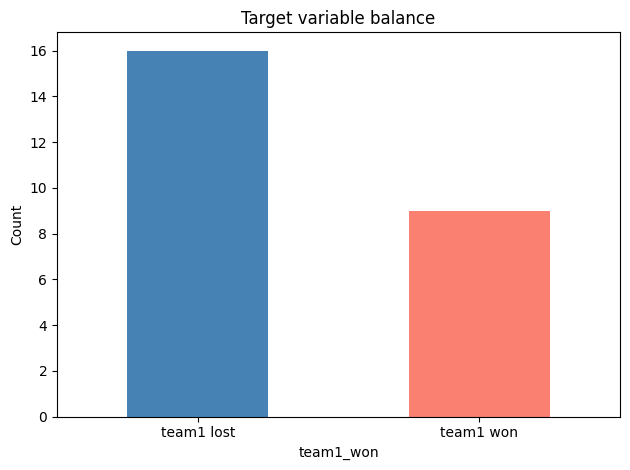

In [54]:
import matplotlib.pyplot as plt

balance = matrix["team1_won"].value_counts()
print("Target balance:")
print(f"  team1 won  : {balance.get(1, 0)} matches ({balance.get(1,0)/len(matrix)*100:.1f}%)")
print(f"  team1 lost : {balance.get(0, 0)} matches ({balance.get(0,0)/len(matrix)*100:.1f}%)")

balance.plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Target variable balance")
plt.xticks([0, 1], ["team1 lost", "team1 won"], rotation=0)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

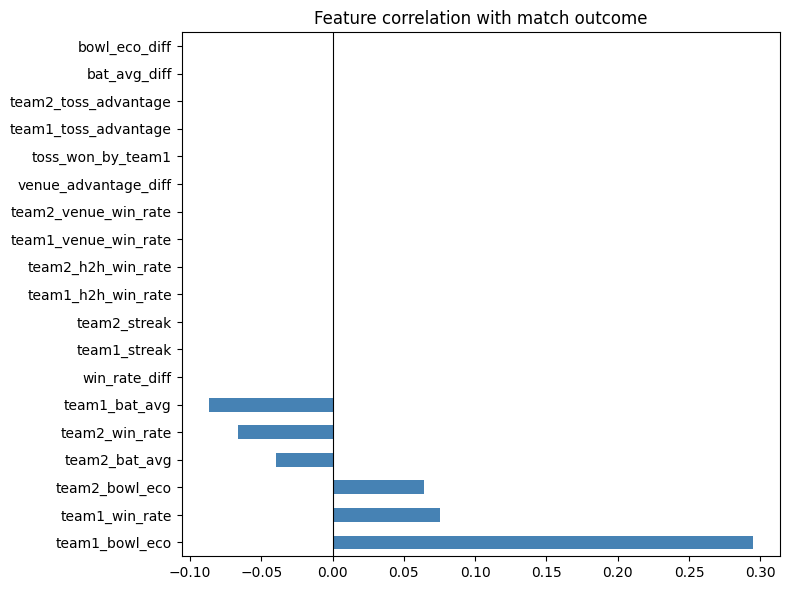

In [55]:
feature_cols = [
    "team1_win_rate", "team2_win_rate", "win_rate_diff",
    "team1_streak", "team2_streak",
    "team1_h2h_win_rate", "team2_h2h_win_rate",
    "team1_venue_win_rate", "team2_venue_win_rate", "venue_advantage_diff",
    "toss_won_by_team1", "team1_toss_advantage", "team2_toss_advantage",
    "team1_bat_avg", "team2_bat_avg", "bat_avg_diff",
    "team1_bowl_eco", "team2_bowl_eco", "bowl_eco_diff",
]

correlations = (
    matrix[feature_cols + ["team1_won"]]
    .corr()["team1_won"]
    .drop("team1_won")
    .sort_values(ascending=False)
)

correlations.plot(kind="barh", figsize=(8, 6), color="steelblue")
plt.title("Feature correlation with match outcome")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

In [61]:
(
    X_train, X_test,
    X_train_scaled, X_test_scaled,
    y_train, y_test,
    class_weight, matrix
) = prepare_data()

Loaded feature matrix: (25, 30)

=== Data Quality Report ===
Total rows       : 25
Total features   : 20

Nulls found:
win_rate_diff           23
team1_streak            23
team2_streak            23
team1_h2h_win_rate      23
team2_h2h_win_rate      23
h2h_total               23
team1_venue_win_rate    23
team2_venue_win_rate    23
venue_advantage_diff    23
toss_won_by_team1       23
team1_toss_advantage    23
team2_toss_advantage    23
bat_avg_diff            23
bowl_eco_diff           23
dtype: int64

Target balance:
  team1 won  : 36.0%
  team1 lost : 64.0%

Train size : 20 matches
Test size  : 5 matches
Scaler saved to models/scaler.pkl
Class weights: {0: 1.0, 1: np.float64(1.857)}


In [62]:
print("=== Sanity Checks ===\n")

# Win rates should be between 0 and 1
assert matrix["team1_win_rate"].between(0, 1).all(), "team1_win_rate out of range"
assert matrix["team2_win_rate"].between(0, 1).all(), "team2_win_rate out of range"
print("Win rates in range [0,1]          ✓")

# Streaks should be between -10 and +10
assert matrix["team1_streak"].between(-10, 10).all(), "team1_streak out of range"
print("Streaks in range [-10, +10]       ✓")

# Target should only be 0 or 1
assert matrix["team1_won"].isin([0, 1]).all(), "target has invalid values"
print("Target is binary (0/1)            ✓")

# No duplicate match IDs
assert matrix["match_id"].nunique() == len(matrix), "duplicate match IDs found"
print("No duplicate match IDs            ✓")

# H2H win rates should sum to ~1
h2h_sum = (matrix["team1_h2h_win_rate"] + matrix["team2_h2h_win_rate"]).round(2)
assert (h2h_sum == 1.0).all(), "H2H win rates don't sum to 1"
print("H2H win rates sum to 1.0          ✓")

print("\nAll checks passed — feature matrix is ready for Block 3!")

=== Sanity Checks ===

Win rates in range [0,1]          ✓
Streaks in range [-10, +10]       ✓
Target is binary (0/1)            ✓
No duplicate match IDs            ✓
H2H win rates sum to 1.0          ✓

All checks passed — feature matrix is ready for Block 3!


In [58]:
print("=== Feature Matrix Summary ===\n")
print(f"Total matches        : {len(matrix)}")
print(f"Total features       : {len(feature_cols)}")
print(f"Date range           : {matrix['match_date'].min()} → {matrix['match_date'].max()}")
print(f"Teams represented    : {pd.concat([matrix['team1'], matrix['team2']]).nunique()}")
print(f"\nTop 3 most predictive features:")
print(correlations.abs().sort_values(ascending=False).head(3).to_string())


=== Feature Matrix Summary ===

Total matches        : 25
Total features       : 19
Date range           : 2026-03-25 → 2026-04-13
Teams represented    : 10

Top 3 most predictive features:
team1_bowl_eco    0.294684
team1_bat_avg     0.086749
team1_win_rate    0.075401
